# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [1]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_genes_15 = pd.read_csv("genes.csv", index_col="Unnamed: 0")
df_genes_15

,Tamanho,Inicio,Qtd_a,Tem_hu
BRCA1,5,BR,1,False
TP53,4,TP,0,False
EGFR,4,EG,0,False
CFTR,4,CF,0,False
APOE,4,AP,1,False


In [3]:
df_genes_15['id_entrez'] = [
    'NM_007294.4',
    'NM_000546.6',
    'NM_005228.5',
    'NM_000492.4',
    'NM_000041.4'
]

df_genes_15['id_protein'] = [
    'NP_009225.1',
    'NP_000537.3',
    'NP_005219.2',
    'NP_000483.3',
    'NP_000032.1'
]
df_genes_15

,Tamanho,Inicio,Qtd_a,Tem_hu,id_entrez,id_protein
BRCA1,5,BR,1,False,NM_007294.4,NP_009225.1
TP53,4,TP,0,False,NM_000546.6,NP_000537.3
EGFR,4,EG,0,False,NM_005228.5,NP_005219.2
CFTR,4,CF,0,False,NM_000492.4,NP_000483.3
APOE,4,AP,1,False,NM_000041.4,NP_000032.1


In [4]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "ozoriosophiia@gmail.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [5]:
for index in df_genes_15.index:
    id_gene = df_genes_15.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

BRCA1 NP_009225.1
TP53 NP_000537.3
EGFR NP_005219.2
CFTR NP_000483.3
APOE NP_000032.1


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [6]:
from Bio import SeqIO

def ler_fasta(nome_gene):
    arquivo = f"{nome_gene}.fasta"
    record = SeqIO.read(arquivo, "fasta")
    return str(record.seq)

# Criar a coluna 'sequencia'
df_genes_15['sequencia'] = df_genes_15.index.map(ler_fasta)
df_genes_15.head()

,Tamanho,Inicio,Qtd_a,Tem_hu,id_entrez,id_protein,sequencia
BRCA1,5,BR,1,False,NM_007294.4,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...
TP53,4,TP,0,False,NM_000546.6,NP_000537.3,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
EGFR,4,EG,0,False,NM_005228.5,NP_005219.2,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...
CFTR,4,CF,0,False,NM_000492.4,NP_000483.3,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...
APOE,4,AP,1,False,NM_000041.4,NP_000032.1,MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWEL...


In [7]:
def contar_aminoacidos(seq):
    return pd.Series(list(seq)).value_counts()

frequencias = df_genes_15['sequencia'].apply(contar_aminoacidos)

# Preencher valores ausentes com 0
frequencias = frequencias.fillna(0).astype(int)

# Colocar o nome do gene como índice
frequencias.index = df_genes_15.index  
frequencias = frequencias.reset_index().rename(columns={'index': 'gene'})

df_frequencias = frequencias.copy()
df_frequencias

,gene,S,E,L,K,N,T,V,Q,P,...,D,A,I,R,H,F,C,Y,M,W
0,BRCA1,224,198,156,137,121,111,101,97,96,...,85,84,77,76,49,49,44,31,30,10
1,TP53,38,30,32,20,14,22,18,15,45,...,20,24,8,26,12,11,10,9,12,4
2,EGFR,84,77,111,66,66,64,70,49,75,...,61,72,69,60,31,36,60,36,25,13
3,CFTR,123,93,183,92,54,83,90,67,45,...,58,83,119,78,25,85,18,40,37,23
4,APOE,14,40,41,13,1,12,24,32,8,...,11,39,2,34,2,4,2,4,8,8


In [26]:
df_frequencias.to_csv("frequencias.csv", index=False)

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [8]:
valinas = df_frequencias[['gene', 'V']]
gene_max = df_frequencias.loc[df_frequencias['V'].idxmax()]

print(f"O número de valinas presentes em cada um dos genes é:\n{valinas}")
print(f"O gene com mais valina é: {gene_max['gene']}")


O número de valinas presentes em cada um dos genes é:
    gene    V
0  BRCA1  101
1   TP53   18
2   EGFR   70
3   CFTR   90
4   APOE   24
O gene com mais valina é: BRCA1


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [9]:
media = df_frequencias['S'].mean()
mediana = df_frequencias['S'].median()
moda = df_frequencias['S'].mode()

print(f"Média: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda.values}")

Média: 96.6
Mediana: 84.0
Moda: [ 14  38  84 123 224]


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

In [10]:
import matplotlib.pyplot as plt

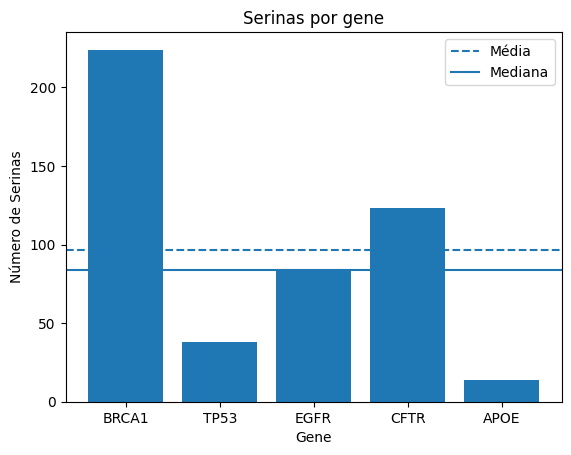

In [11]:
plt.figure()
plt.bar(df_frequencias['gene'], df_frequencias['S'])

plt.axhline(df_frequencias['S'].mean(), linestyle='--', label='Média')
plt.axhline(df_frequencias['S'].median(), linestyle='-', label='Mediana')

plt.legend()
plt.xlabel("Gene")
plt.ylabel("Número de Serinas")
plt.title("Serinas por gene")
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [12]:
def histograma_aminoacido(df, aa):
    aa = aa.upper()
    
    if aa not in df.columns:
        print(f"Aminoácido '{aa}' não encontrado no DataFrame.")
        return
    
    dados = df[aa]
    genes = df['gene']
    
    media = dados.mean()
    mediana = dados.median()
    
    plt.figure()
    plt.bar(genes, dados)
    
    # Linhas de média e mediana
    plt.axhline(media, linestyle='--', label=f'Média ({media:.2f})')
    plt.axhline(mediana, linestyle='-', label=f'Mediana ({mediana:.2f})')
    
    plt.title(f"Número de {aa} por gene")
    plt.xlabel("Gene")
    plt.ylabel(f"Quantidade de {aa}")
    
    plt.legend()
    plt.xticks(rotation=45)
    
    plt.show()
    

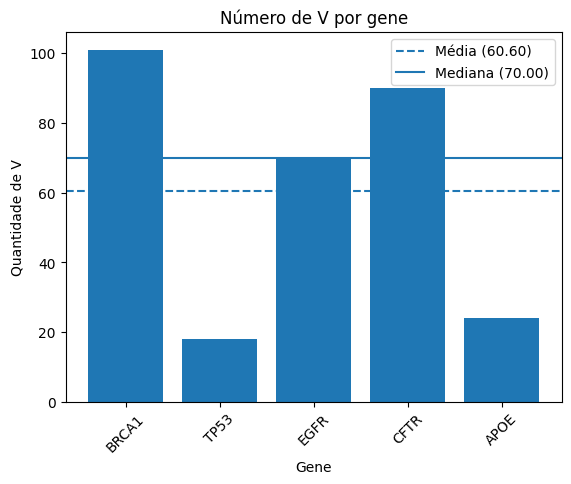

In [13]:
histograma_aminoacido(df_frequencias, 'V')  # Serina

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

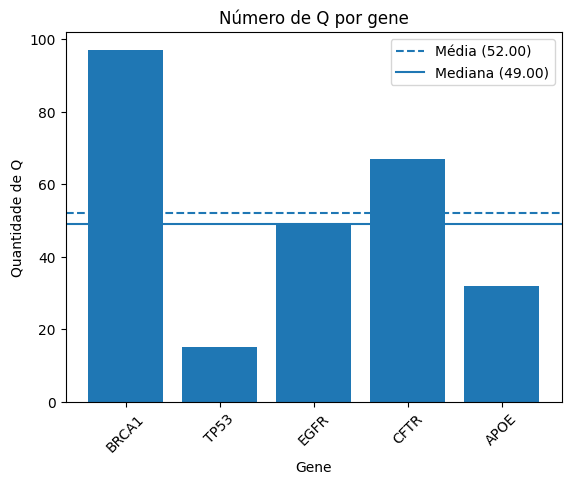

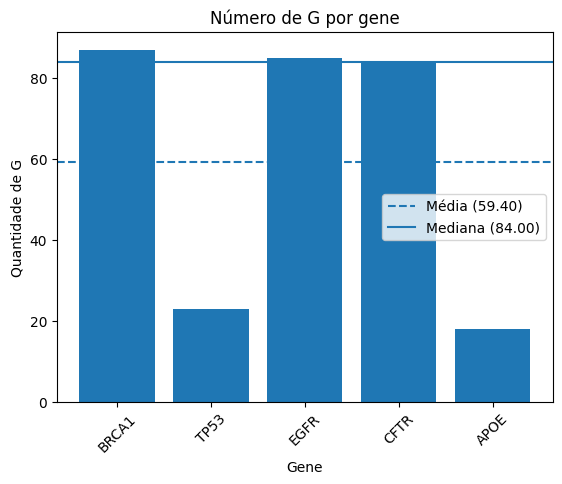

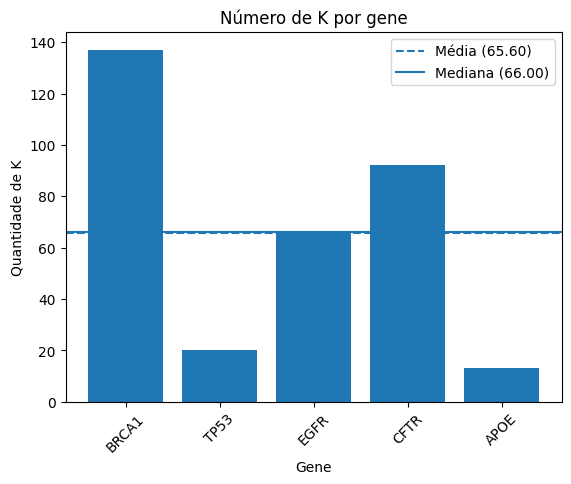

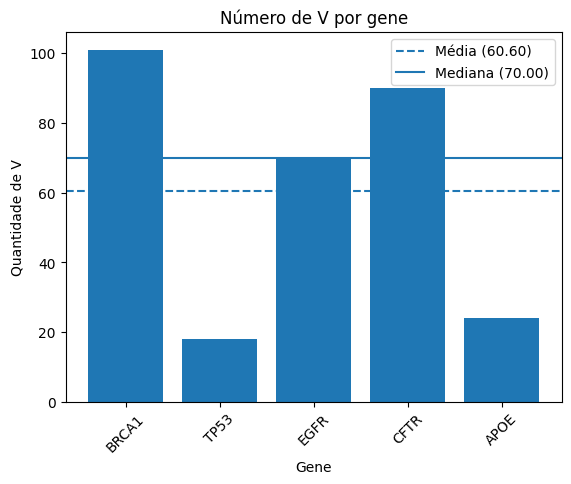

In [14]:
histograma_aminoacido(df_frequencias, 'Q')  # Glutamina
histograma_aminoacido(df_frequencias, 'G')  # Glicina
histograma_aminoacido(df_frequencias, 'K')  # Lisina
histograma_aminoacido(df_frequencias, 'V')  # Valina

In [16]:
aa_lista = ['Q', 'G', 'K', 'V']

menor_aa = None
menor_dif = float('inf')  # começa com infinito

for aa in aa_lista:
    media = df_frequencias[aa].mean()
    mediana = df_frequencias[aa].median()
    diferenca = abs(media - mediana)
    
    if diferenca < menor_dif:
        menor_dif = diferenca
        menor_aa = aa

print(f"O aminoácido com menor diferença é o {menor_aa}, com: {menor_dif:.2f}")

O aminoácido com menor diferença é o K, com: 0.40


## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [19]:
primeiros_3 = df_frequencias.head(3)
media = primeiros_3['C'].mean()
mediana = primeiros_3['C'].median()

print(f"Média de Cisteína: {media}")
print(f"Mediana de Cisteína: {mediana}")


Média de Cisteína: 38.0
Mediana de Cisteína: 44.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [24]:
df_frequencias['media_aa'] = df_frequencias.drop(columns=['gene']).mean(axis=1)
gene_maior = df_frequencias.loc[df_frequencias['media_aa'].idxmax()]

print(f"Maior gene (pela média de aa): {gene_maior['gene']}")
print(f"Média de aa: {gene_maior['media_aa']:.2f}")

Maior gene (pela média de aa): BRCA1
Média de aa: 93.15


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [25]:
gene_menor = df_frequencias.loc[df_frequencias['media_aa'].idxmin()]

print(f"Menor gene (pela média de aa): {gene_menor['gene']}")
print(f"Média de aa: {gene_menor['media_aa']:.2f}")

Menor gene (pela média de aa): APOE
Média de aa: 15.85
